<a href="https://colab.research.google.com/github/Ali-Hamza-developer/pytorch/blob/main/03_manual_training_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Cancer Classification — PyTorch from Scratch

**Ali Hamza**
🔗 [LinkedIn](https://www.linkedin.com/in/alihamzastudent/)

---

This notebook builds a **binary classifier from scratch in PyTorch** (no `nn.Module`, no built-in loss function) to predict whether a tumor is **Malignant (M)** or **Benign (B)**, using the Breast Cancer Wisconsin dataset.

Everything below — the math, the gradient updates, the training loop — is written manually so the mechanics of a neural network are fully visible.

## 📌 What this notebook covers

1. Loading and cleaning the dataset
2. Train / test split
3. Feature scaling
4. Label encoding
5. Converting data into PyTorch tensors
6. Defining a single-neuron model manually (weights, bias, forward pass, loss)
7. Writing the training loop by hand (forward → loss → backward → update → zero grad)
8. Evaluating the trained model

> 💡 **Note:** This is intentionally a *manual* implementation — `torch.nn.Linear`, `torch.nn.BCELoss`, and `torch.optim` are **not** used here. The goal is to understand what those tools do internally before relying on them.

### 🔄 Pipeline overview

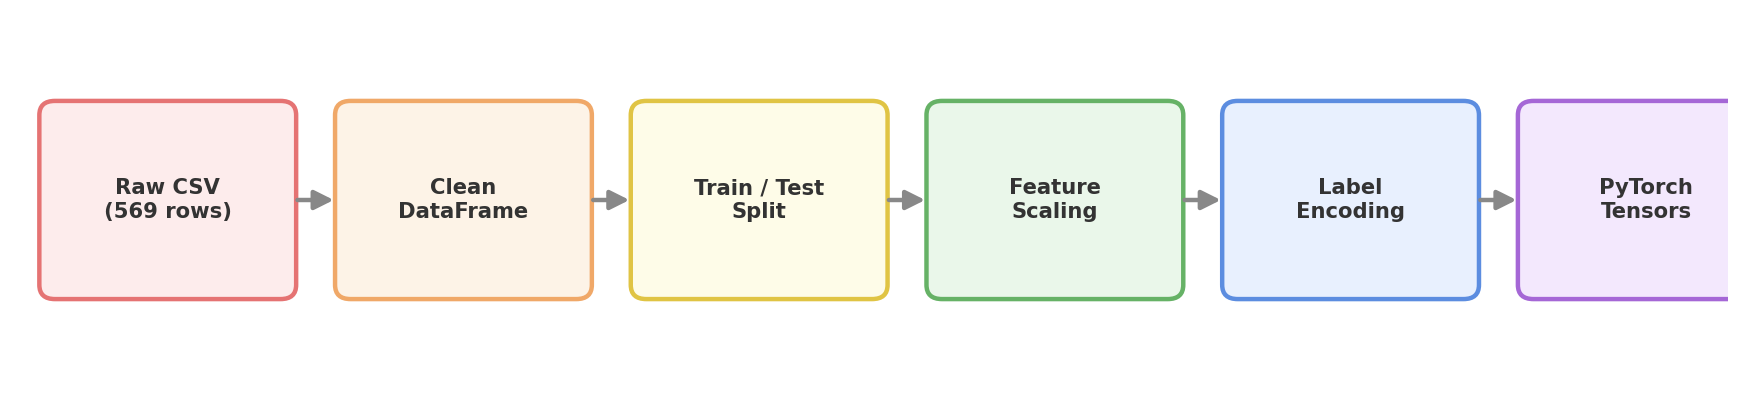

## Step 1 — Import Libraries

In [1]:
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder

## Step 2 — Load the Dataset

> **Important:** Reading data is the very first step of any ML pipeline. Nothing can happen before this — no scaling, no tensors, no training.

In [2]:
# load dataset directly from a CSV hosted on GitHub
df = pd.read_csv('https://raw.githubusercontent.com/gscdit/Breast-Cancer-Detection/refs/heads/master/data.csv')

# quick look at the first few rows
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [3]:
# check dataset size: (rows, columns)
df.shape

(569, 33)

### Cleaning the data

The dataset has two columns we don't need:
- `id` → just a row identifier, has no predictive value
- `Unnamed: 32` → an empty leftover column from the CSV export

> ⚠️ **Common mistake:** Forgetting to drop the `id` column will let the model "cheat" by memorizing ID numbers instead of learning real patterns.

In [4]:
# remove unnecessary columns permanently (inplace=True)
df.drop(columns=['id', 'Unnamed: 32'], inplace=True)

# confirm the columns are gone
df.head()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Step 3 — Train / Test Split

We split the data so the model is trained on one portion and tested on data it has **never seen** — this is how we check if it actually learned, instead of memorized.

- `X` = all columns except the first (the features)
- `y` = the first column, `diagnosis` (the label we want to predict)
- `test_size=0.2` → 80% training data, 20% testing data

In [5]:
X_train, X_test, y_train, y_test = train_test_split(df.iloc[:, 1:], df.iloc[:, 0], test_size=0.2)

## Step 4 — Feature Scaling

The dataset has columns on very different numeric ranges (e.g. `area_mean` is in the hundreds while `smoothness_mean` is a small decimal). Neural networks train faster and more reliably when every feature is on a similar scale.

`StandardScaler` transforms each feature to have **mean = 0** and **standard deviation = 1**.

> ⚠️ **Important rule:** Fit the scaler only on `X_train`, then just `transform` (not `fit_transform`) on `X_test`. This prevents the test set from "leaking" information into training.

In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # learn mean/std from training data, then scale it
X_test = scaler.transform(X_test)         # apply the SAME scaling to test data (no re-fitting)

In [7]:
# scaled X_train — values are now centered around 0
X_train

array([[-1.13736469,  0.47397374, -1.15596731, ..., -1.35274167,
        -0.88587517, -0.16859684],
       [-0.53269099, -0.95849187, -0.55816965, ..., -0.89386855,
        -0.36066984, -0.22554635],
       [ 1.69652083,  1.78372402,  1.68821032, ...,  1.56681351,
         0.66617389, -0.41291024],
       ...,
       [-0.16765755, -0.09004485, -0.15116707, ...,  0.48937881,
        -0.35225309, -0.38215751],
       [ 0.92186972,  1.4840154 ,  0.91373563, ..., -0.05627482,
        -2.14165456, -0.87647927],
       [ 0.28097133, -0.61158505,  0.27963448, ...,  0.17955853,
         0.90857635,  0.78758546]])

In [8]:
# y_train is still text labels ('M' / 'B') at this point
y_train

,diagnosis
425,B
324,B
366,M
238,B
84,B
...,...
260,M
197,M
396,B
213,M


## Step 5 — Label Encoding

PyTorch works with numbers, not text. `LabelEncoder` converts the diagnosis labels into numbers:
- `M` (Malignant) → `1`
- `B` (Benign) → `0`

(the exact mapping is decided alphabetically by scikit-learn, but B/M will map to 0/1)

In [9]:
encoder = LabelEncoder()
y_train = encoder.fit_transform(y_train)   # learn the mapping + apply it
y_test = encoder.transform(y_test)         # apply the SAME mapping to test labels

In [10]:
# y_train is now an array of 0s and 1s
y_train

array([0, 0, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1,
       1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 1, 1, 0, 1, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 1,
       1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 0,
       1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0,

## Step 6 — Convert NumPy Arrays to PyTorch Tensors

PyTorch models don't operate on NumPy arrays or pandas DataFrames directly — everything needs to be a **tensor** so it can support gradient tracking (`autograd`) and run on GPU if needed.

`torch.from_numpy()` converts an array to a tensor while keeping the same underlying data.

In [11]:
X_train_tensor = torch.from_numpy(X_train)
X_test_tensor = torch.from_numpy(X_test)
y_train_tensor = torch.from_numpy(y_train)
y_test_tensor = torch.from_numpy(y_test)

In [12]:
# shape check: (455 training samples, 30 features)
X_train_tensor.shape

torch.Size([455, 30])

In [13]:
# shape check for the labels
y_train_tensor.shape

torch.Size([455])

## Step 7 — Defining the Model (Manually)

This is a **single neuron** (logistic regression) built from scratch — no `nn.Linear`, no `nn.Module`. Every input feature gets multiplied by its own weight, all of those are summed with a bias added, and the result is squashed into a 0–1 probability by a sigmoid function.

### How one neuron works

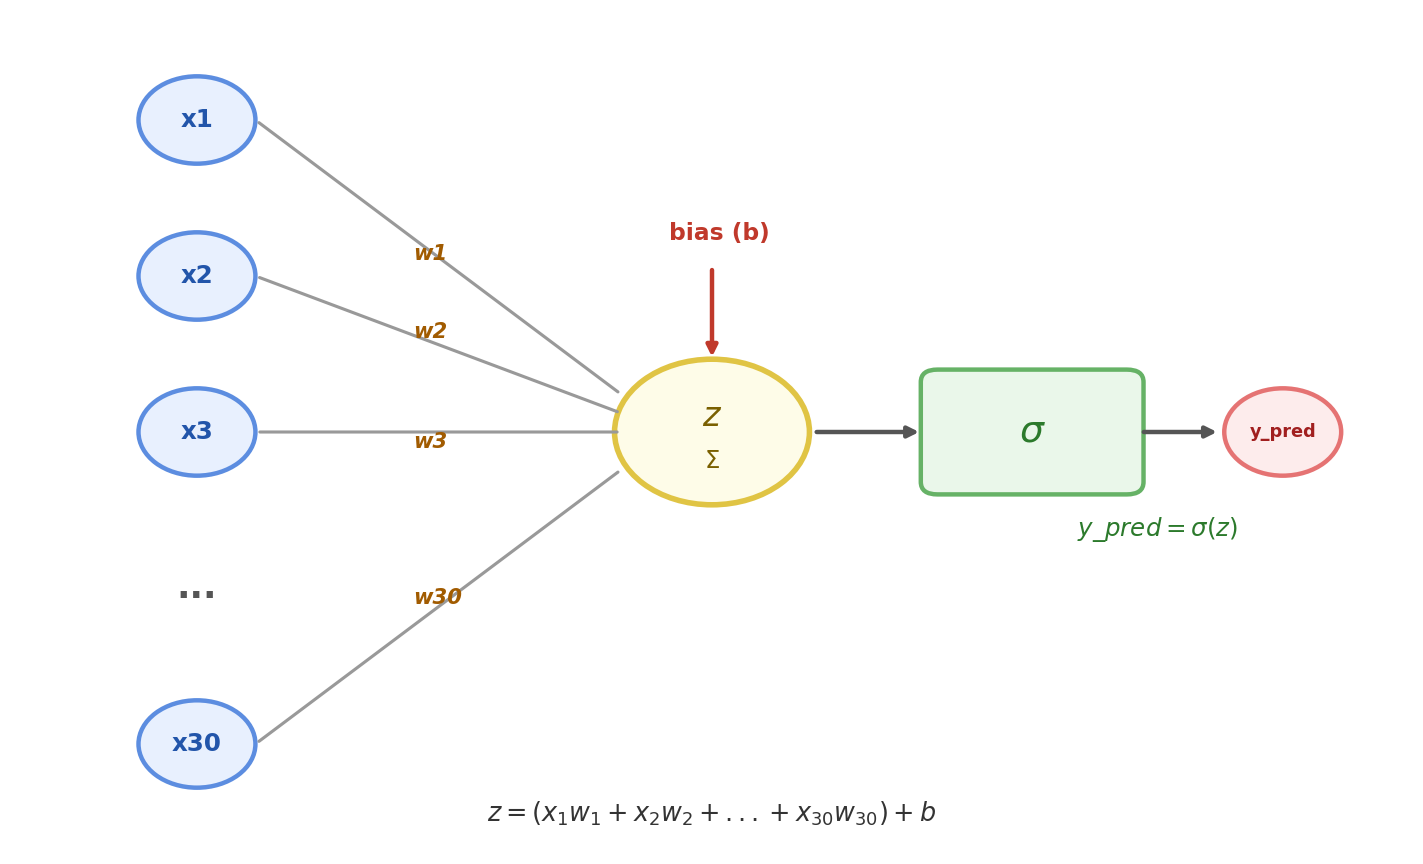

**Breaking that down:**
- **weights (`w`)** — one learnable number per input feature (30 of them here). They control *how much* each feature influences the prediction.
- **bias (`b`)** — one learnable number added to the weighted sum. It lets the model shift its decision boundary, even when all inputs are 0.
- **z** — the raw weighted sum: `z = (X · weights) + b`
- **sigmoid (σ)** — squashes `z` into a probability between 0 and 1: values close to 1 → predicted Malignant, close to 0 → predicted Benign

### The loss function (manual Binary Cross-Entropy)

We are **not** using `torch.nn.BCELoss`. Instead the formula is written directly:

`loss = -mean( y·log(y_pred) + (1-y)·log(1-y_pred) )`

This penalizes the model heavily when it is confident **and wrong**, and lightly when it's right (or unsure).

In [14]:
class MySimpleNN():

    def __init__(self, X):
        # one weight per input feature, randomly initialized, gradient tracking ON
        self.weights = torch.rand(X.shape[1], 1, dtype=torch.float64, requires_grad=True)
        # single bias value, starts at 0, gradient tracking ON
        self.bias = torch.zeros(1, dtype=torch.float64, requires_grad=True)

    def forward(self, X):
        # weighted sum of inputs + bias
        z = torch.matmul(X, self.weights) + self.bias
        # squash into a 0-1 probability
        y_pred = torch.sigmoid(z)
        return y_pred

    def loss_function(self, y_pred, y):
        # clamp predictions so we never take log(0), which would be -infinity
        epsilon = 1e-7
        y_pred = torch.clamp(y_pred, epsilon, 1 - epsilon)

        # manual Binary Cross-Entropy loss
        loss = -(y_train_tensor * torch.log(y_pred) + (1 - y_train_tensor) * torch.log(1 - y_pred)).mean()
        return loss

## Step 8 — Important Parameters

- **`learning_rate`** — how big a step we take when updating weights/bias after each epoch. Too high → the model overshoots and never settles. Too low → training is painfully slow.
- **`epochs`** — how many times the model sees the *entire* training set.

In [15]:
learning_rate = 0.1
epochs = 100

## Step 9 — Training Pipeline (Manual Loop)

This is the core of learning. Every epoch repeats the same 5-step cycle:

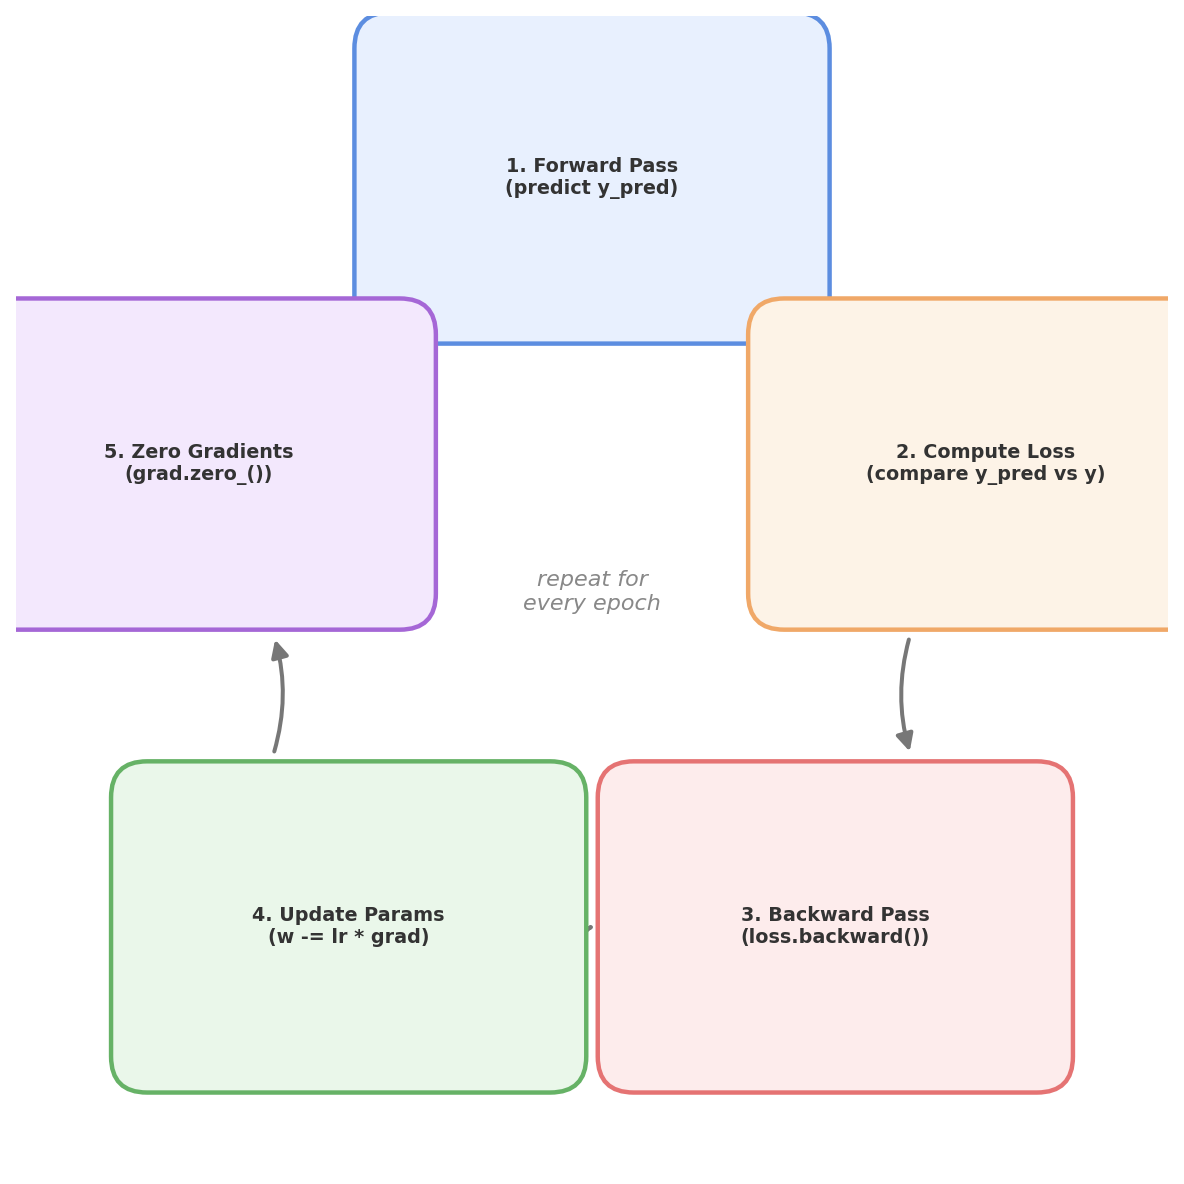

1. **Forward pass** — run the current weights/bias through the model to get a prediction
2. **Compute loss** — measure how wrong that prediction was
3. **Backward pass** — `loss.backward()` uses autograd to calculate *how much* each weight and the bias contributed to the error (the gradients)
4. **Update parameters** — nudge weights/bias in the direction that reduces the loss, scaled by `learning_rate`
5. **Zero gradients** — PyTorch accumulates gradients by default, so they must be reset to 0 before the next epoch, otherwise old and new gradients would add up incorrectly

> ⚠️ **Why `with torch.no_grad():`?** The parameter update itself should NOT be tracked by autograd — we're manually changing the weights, not doing a differentiable operation. Skipping this would cause errors or corrupt the gradient graph.

In [16]:
# create model
model = MySimpleNN(X_train_tensor)

# define loop
for epoch in range(epochs):

  # forward pass
  y_pred = model.forward(X_train_tensor)

  # loss calculate
  loss = model.loss_function(y_pred, y_train_tensor)

  # backward pass
  loss.backward()

  # parameters update
  with torch.no_grad():
    model.weights -= learning_rate * model.weights.grad
    model.bias -= learning_rate * model.bias.grad

  # zero gradients
  model.weights.grad.zero_()
  model.bias.grad.zero_()

  # print loss in each epoch
  print(f'Epoch: {epoch + 1}, Loss: {loss.item()}')

Epoch: 1, Loss: 3.672746542324103
Epoch: 2, Loss: 3.5630966003013618
Epoch: 3, Loss: 3.447670491793532
Epoch: 4, Loss: 3.331500120872421
Epoch: 5, Loss: 3.2070365473436904
Epoch: 6, Loss: 3.080938188574816
Epoch: 7, Loss: 2.95023744540652
Epoch: 8, Loss: 2.8183493617215154
Epoch: 9, Loss: 2.6795851071988506
Epoch: 10, Loss: 2.529402937637087
Epoch: 11, Loss: 2.3694978638419286
Epoch: 12, Loss: 2.2137018730406135
Epoch: 13, Loss: 2.060592940711749
Epoch: 14, Loss: 1.9127154209767316
Epoch: 15, Loss: 1.7689643034648967
Epoch: 16, Loss: 1.630153772026699
Epoch: 17, Loss: 1.4988866091311333
Epoch: 18, Loss: 1.378072567224818
Epoch: 19, Loss: 1.270058427033614
Epoch: 20, Loss: 1.1752928683902895
Epoch: 21, Loss: 1.093545571380973
Epoch: 22, Loss: 1.0239141695175056
Epoch: 23, Loss: 0.9653507768645803
Epoch: 24, Loss: 0.9168144014836526
Epoch: 25, Loss: 0.8771783362768013
Epoch: 26, Loss: 0.8451625274217275
Epoch: 27, Loss: 0.8193898256632396
Epoch: 28, Loss: 0.7985477429182073
Epoch: 29, Lo

> 📉 **What to look for:** The loss printed each epoch should generally trend **downward**. If it's flat or increasing, the learning rate is usually the first thing to check.

## Step 10 — Model Evaluation

Now we test the trained weights and bias on data the model has **never seen** (`X_test_tensor`).

- `torch.no_grad()` — evaluation doesn't need gradients, so we disable tracking to save memory/computation
- predictions above `0.9` are classified as `1` (Malignant), otherwise `0` (Benign) — this is a stricter-than-usual threshold (default is normally `0.5`)
- **accuracy** = fraction of predictions that matched the true label

In [17]:
# model evaluation
with torch.no_grad():
  y_pred = model.forward(X_test_tensor)
  y_pred = (y_pred > 0.9).float()
  accuracy = (y_pred == y_test_tensor).float().mean()
  print(f'Accuracy: {accuracy.item()}')

Accuracy: 0.5701754093170166


---

## ✅ Summary

- Built a single-neuron classifier **entirely by hand** — weights, bias, sigmoid, BCE loss, gradient updates
- No `nn.Module`, no `nn.Linear`, no `nn.BCELoss`, no `torch.optim` — every step was explicit
- This manual version is exactly what those built-in PyTorch tools do *internally* — worth revisiting once high-level `nn.Module`-based models are introduced, to compare

---
**Ali Hamza** · [LinkedIn](https://www.linkedin.com/in/alihamzastudent/)